In [8]:
# White House Visitor Logs (Weeks 3 & 4 Exercise) — Visual Story (Python)
# Author: Shaghayegh Malekshahi
# Course: DSC 530 — Data Presentation
# Term: Winter 2026

# 1) IMPORTS
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# A) CONFIGURATION

EXTRACT_DIR = r"C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment"
OUTPUT_DIR  = r"C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(os.path.join(OUTPUT_DIR, "figures")).mkdir(parents=True, exist_ok=True)

# If True, uses all CSVs in the folder (slower but acceptable).
# If False, uses a curated list of 6 (>=5 required).
USE_ALL_DATASETS = False

DEFAULT_PICK = [
    "2022.01_WAVES-ACCESS-RECORDS.csv",
    "2022.06_WAVES-ACCESS-RECORDS.csv",
    "2022.12_WAVES-ACCESS-RECORDS.csv",
    "2023.03_WAVES-ACCESS-RECORDS.csv",
    "2023.06_WAVES-ACCESS-RECORDS.csv",
    "2023.12_WAVES-ACCESS-RECORDS.csv",
]

In [4]:
# B) FILE DISCOVERY 

all_csvs = sorted(glob.glob(os.path.join(EXTRACT_DIR, "*.csv")))
if not all_csvs:
    raise FileNotFoundError(f"No CSV files found in: {EXTRACT_DIR}")

if USE_ALL_DATASETS:
    selected_csvs = all_csvs
else:
    picks = [os.path.join(EXTRACT_DIR, fn) for fn in DEFAULT_PICK]
    selected_csvs = [p for p in picks if os.path.exists(p)]

    # If some picked months aren't present, fall back to first 6 found
    if len(selected_csvs) < 5:
        selected_csvs = all_csvs[:6]

print(f"Found {len(all_csvs)} total CSVs.")
print(f"Using {len(selected_csvs)} CSVs (>=5 required):")
for f in selected_csvs:
    print(" -", os.path.basename(f))

Found 25 total CSVs.
Using 6 CSVs (>=5 required):
 - 2022.01_WAVES-ACCESS-RECORDS.csv
 - 2022.06_WAVES-ACCESS-RECORDS.csv
 - 2022.12_WAVES-ACCESS-RECORDS.csv
 - 2023.03_WAVES-ACCESS-RECORDS.csv
 - 2023.06_WAVES-ACCESS-RECORDS.csv
 - 2023.12_WAVES-ACCESS-RECORDS.csv


In [5]:
# C) LOADING + COLUMN STANDARDIZATION

def normalize_col(c: str) -> str:
    c = c.strip()
    c = re.sub(r"[^\w]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c.upper()

CANON_MAP = {
    "APPOINTMENT_START_DATE": "APPT_START_DATE",
    "APPOINTMENT_END_DATE": "APPT_END_DATE",
    "APPOINTMENT_MADE_DATE": "APPT_MADE_DATE",
    "APPOINTMENT_CANCEL_DATE": "APPT_CANCEL_DATE",
    "MEETING_LOCATION": "MEETING_LOC",
    "LAST_ENTRY_DATE": "LASTENTRYDATE",
    "RELEASE_DATE": "RELEASEDATE",
}

KEEP_CANON = [
    "TOA",                 # arrival time (often best indicator of actual visit time)
    "APPT_START_DATE",      # fallback if TOA missing
    "APPT_END_DATE",
    "APPT_MADE_DATE",
    "APPT_CANCEL_DATE",
    "TOTAL_PEOPLE",
    "MEETING_LOC",
    "MEETING_ROOM",
    "ACCESS_TYPE",
    "LASTENTRYDATE",        # fallback if TOA and APPT missing
    "RELEASEDATE",
]

def infer_month_from_filename(filename: str) -> str:
    m = re.search(r"(20\d{2})[._-](\d{2})", filename)
    if m:
        return f"{m.group(1)}-{m.group(2)}"
    y = re.search(r"(20\d{2})", filename)
    return f"{y.group(1)}-00" if y else "unknown"

frames = []
for fp in selected_csvs:
    d = pd.read_csv(fp, low_memory=False)

    # Normalize column names
    d.columns = [normalize_col(c) for c in d.columns]
    d = d.rename(columns={c: CANON_MAP.get(c, c) for c in d.columns})

    # Keep only useful columns that exist in this file
    keep = [c for c in KEEP_CANON if c in d.columns]
    dd = d[keep].copy()

    # Provenance
    dd["SOURCE_FILE"] = os.path.basename(fp)
    dd["SOURCE_MONTH_FILE"] = infer_month_from_filename(os.path.basename(fp))

    frames.append(dd)

df = pd.concat(frames, ignore_index=True)
print("Combined rows:", len(df))

Combined rows: 392390


In [6]:
# D) CLEANING + DATETIME FEATURE CREATION

# Mixed date formats exist across files; format="mixed" handles both:
date_cols = ["TOA", "APPT_START_DATE", "APPT_END_DATE", "APPT_MADE_DATE", "APPT_CANCEL_DATE", "LASTENTRYDATE", "RELEASEDATE"]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", format="mixed")

# TOTAL_PEOPLE numeric
if "TOTAL_PEOPLE" in df.columns:
    df["TOTAL_PEOPLE"] = pd.to_numeric(df["TOTAL_PEOPLE"], errors="coerce").fillna(1)
else:
    df["TOTAL_PEOPLE"] = 1

# VISIT_DT: best available timestamp (TOA > APPT_START_DATE > LASTENTRYDATE)
df["VISIT_DT"] = df.get("TOA").fillna(df.get("APPT_START_DATE")).fillna(df.get("LASTENTRYDATE"))

# Remove rows without a usable visit timestamp (documented filter)
df = df[df["VISIT_DT"].notna()].copy()

# Derived time fields
df["VISIT_DATE"]  = df["VISIT_DT"].dt.date
df["VISIT_MONTH"] = df["VISIT_DT"].dt.to_period("M").astype(str)
df["VISIT_DOW"]   = df["VISIT_DT"].dt.day_name()
df["VISIT_HOUR"]  = df["VISIT_DT"].dt.hour

# Save cleaned dataset
clean_path = os.path.join(OUTPUT_DIR, "cleaned_visits.csv")
df.to_csv(clean_path, index=False)
print("Saved cleaned dataset:", clean_path)

Saved cleaned dataset: C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output\cleaned_visits.csv


In [7]:
# E) SIX VISUALIZATIONS
# =======================
plt.rcParams["figure.dpi"] = 140

def save_fig(filename_no_ext: str) -> str:
    path = os.path.join(OUTPUT_DIR, "figures", f"{filename_no_ext}.png")
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    return path

figure_paths = []

# 1) LINE CHART (required list): Daily visit volume
daily = df.groupby("VISIT_DATE").size().reset_index(name="visits")
daily["VISIT_DATE"] = pd.to_datetime(daily["VISIT_DATE"])
daily = daily.sort_values("VISIT_DATE")

plt.figure(figsize=(10,4))
plt.plot(daily["VISIT_DATE"], daily["visits"])
plt.title("Daily Visit Volume (Selected Months)")
plt.xlabel("Date")
plt.ylabel("Number of visits")
figure_paths.append(save_fig("01_line_daily_visits"))

# 2) STACKED BAR WITH TIME (required list): Monthly visits by meeting location (Top 4 + Other)
loc = df["MEETING_LOC"].fillna("Unknown") if "MEETING_LOC" in df.columns else pd.Series(["Unknown"] * len(df))
monthly_loc = df.assign(MEETING_LOC_C=loc).groupby(["VISIT_MONTH","MEETING_LOC_C"]).size().reset_index(name="visits")

top_locs = (monthly_loc.groupby("MEETING_LOC_C")["visits"].sum()
            .sort_values(ascending=False).head(4).index.tolist())

monthly_loc["MEETING_LOC_C"] = monthly_loc["MEETING_LOC_C"].where(
    monthly_loc["MEETING_LOC_C"].isin(top_locs), "Other"
)

pivot_loc = (monthly_loc.groupby(["VISIT_MONTH","MEETING_LOC_C"])["visits"]
             .sum().unstack(fill_value=0).sort_index())

plt.figure(figsize=(10,4.5))
bottom = np.zeros(len(pivot_loc))
for col in pivot_loc.columns:
    plt.bar(pivot_loc.index, pivot_loc[col].values, bottom=bottom, label=col)
    bottom += pivot_loc[col].values

plt.title("Monthly Visits by Meeting Location (Top 4 + Other)")
plt.xlabel("Month")
plt.ylabel("Number of visits")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right", fontsize=8)
figure_paths.append(save_fig("02_stackedbar_monthly_location"))

# 3) BAR CHART (required list): Top 10 meeting rooms
room = df["MEETING_ROOM"].fillna("Unknown") if "MEETING_ROOM" in df.columns else pd.Series(["Unknown"] * len(df))
top_rooms = room.value_counts().head(10).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top_rooms.index, top_rooms.values)
plt.title("Top 10 Meeting Rooms by Visit Count")
plt.xlabel("Number of visits")
plt.ylabel("Meeting room")
figure_paths.append(save_fig("03_bar_top_rooms"))

# 4) SCATTERPLOT WITH TIME (required list): Visit size over time (sampled)
sample = df.sample(min(6000, len(df)), random_state=42)

plt.figure(figsize=(10,4))
plt.scatter(sample["VISIT_DT"], sample["TOTAL_PEOPLE"], s=8, alpha=0.4)
plt.title("Visit Size Over Time (Sampled)")
plt.xlabel("Visit datetime")
plt.ylabel("Total people on record")
figure_paths.append(save_fig("04_scatter_time_total_people"))

# 5) STEP CHART (required list): Cumulative visits
daily_cum = daily.copy()
daily_cum["cum_visits"] = daily_cum["visits"].cumsum()

plt.figure(figsize=(10,4))
plt.step(daily_cum["VISIT_DATE"], daily_cum["cum_visits"], where="post")
plt.title("Cumulative Visits Over Time (Selected Months)")
plt.xlabel("Date")
plt.ylabel("Cumulative visits")
figure_paths.append(save_fig("05_step_cumulative_visits"))

# 6) COLUMN CHART (required list): Visits by day of week
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = df["VISIT_DOW"].value_counts().reindex(dow_order)

plt.figure(figsize=(9,4))
plt.bar(dow_counts.index, dow_counts.values)
plt.title("Visits by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Number of visits")
plt.xticks(rotation=30, ha="right")
figure_paths.append(save_fig("06_column_dow"))

print("\nSaved figures:")
for p in figure_paths:
    print(" -", p)



Saved figures:
 - C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output\figures\01_line_daily_visits.png
 - C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output\figures\02_stackedbar_monthly_location.png
 - C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output\figures\03_bar_top_rooms.png
 - C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output\figures\04_scatter_time_total_people.png
 - C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output\figures\05_step_cumulative_visits.png
 - C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\week 3&4\assignment\output\figures\06_col

JUPYTER OUTPUT VERIFICATION

Cleaned dataset preview (first 10 rows):


,TOA,APPT_START_DATE,APPT_END_DATE,APPT_MADE_DATE,APPT_CANCEL_DATE,TOTAL_PEOPLE,MEETING_LOC,MEETING_ROOM,ACCESS_TYPE,LASTENTRYDATE,RELEASEDATE,SOURCE_FILE,SOURCE_MONTH_FILE,VISIT_DT,VISIT_DATE,VISIT_MONTH,VISIT_DOW,VISIT_HOUR
0,2022-01-01 12:22:00,2022-01-01,2022-01-01 11:59:00,2021-12-31 01:54:00,NaT,1.0,WH,WW-132,VA,2021-12-31 01:54:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-01 12:22:00,2022-01-01,2022-01,Saturday,12
1,NaT,2022-01-02,2022-01-02 11:59:00,2022-01-02 09:03:00,NaT,1.0,WH,WW G47,VA,2022-01-02 09:03:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-02 00:00:00,2022-01-02,2022-01,Sunday,0
2,2022-01-02 10:59:00,2022-01-02,2022-01-02 11:59:00,2021-12-30 04:27:00,NaT,1.0,OEOB,97,VA,2021-12-30 04:27:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-02 10:59:00,2022-01-02,2022-01,Sunday,10
3,2022-01-02 14:01:00,2022-01-02,2022-01-02 11:59:00,2021-12-31 03:03:00,NaT,1.0,WH,WHSR,VA,2021-12-31 03:03:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-02 14:01:00,2022-01-02,2022-01,Sunday,14
4,NaT,2022-01-02,2022-01-02 11:59:00,2021-12-27 04:04:00,NaT,1.0,OEOB,97,VA,2021-12-27 04:04:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-02 00:00:00,2022-01-02,2022-01,Sunday,0
5,NaT,2022-01-03,2022-01-03 11:59:00,2021-12-10 01:00:00,NaT,2.0,OEOB,412A,VA,2021-12-10 01:00:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-03 00:00:00,2022-01-03,2022-01,Monday,0
6,2022-01-03 12:52:00,2022-01-03,2022-01-03 11:59:00,2022-01-02 09:03:00,NaT,1.0,OEOB,386,VA,2022-01-02 09:03:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-03 12:52:00,2022-01-03,2022-01,Monday,12
7,2022-01-03 12:48:00,2022-01-03,2022-01-03 11:59:00,2022-01-03 08:37:00,NaT,1.0,OEOB,South Cour,VA,2022-01-03 08:37:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-03 12:48:00,2022-01-03,2022-01,Monday,12
8,NaT,2022-01-03,2022-01-03 11:59:00,2021-12-29 01:00:00,NaT,3.0,OEOB,226,VA,2021-12-29 01:00:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-03 00:00:00,2022-01-03,2022-01,Monday,0
9,NaT,2022-01-03,2022-01-03 11:59:00,2021-12-10 01:00:00,NaT,2.0,OEOB,412A,VA,2021-12-10 01:00:00,2022-05-04,2022.01_WAVES-ACCESS-RECORDS.csv,2022-01,2022-01-03 00:00:00,2022-01-03,2022-01,Monday,0



Dataset summary:
Total rows after cleaning: 392390
Number of datasets used: 6

Datasets included:


SOURCE_FILE
2023.12_WAVES-ACCESS-RECORDS.csv    122138
2023.06_WAVES-ACCESS-RECORDS.csv     94836
2022.12_WAVES-ACCESS-RECORDS.csv     87061
2023.03_WAVES-ACCESS-RECORDS.csv     69770
2022.06_WAVES-ACCESS-RECORDS.csv     17400
2022.01_WAVES-ACCESS-RECORDS.csv      1185
Name: count, dtype: int64


Displaying saved figures:



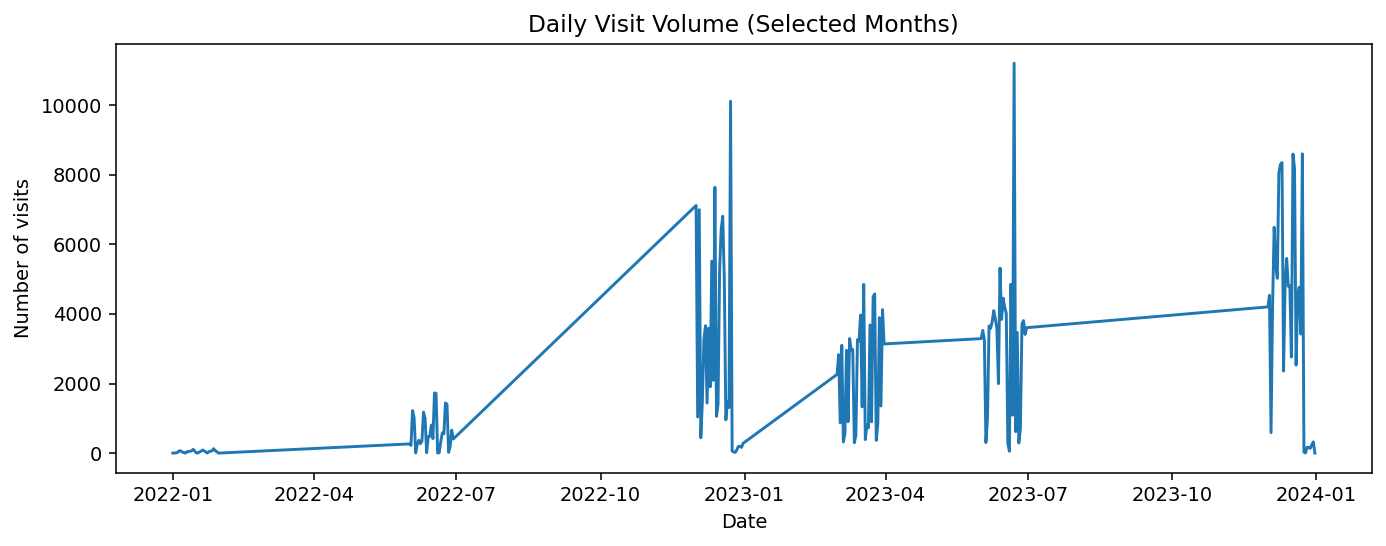

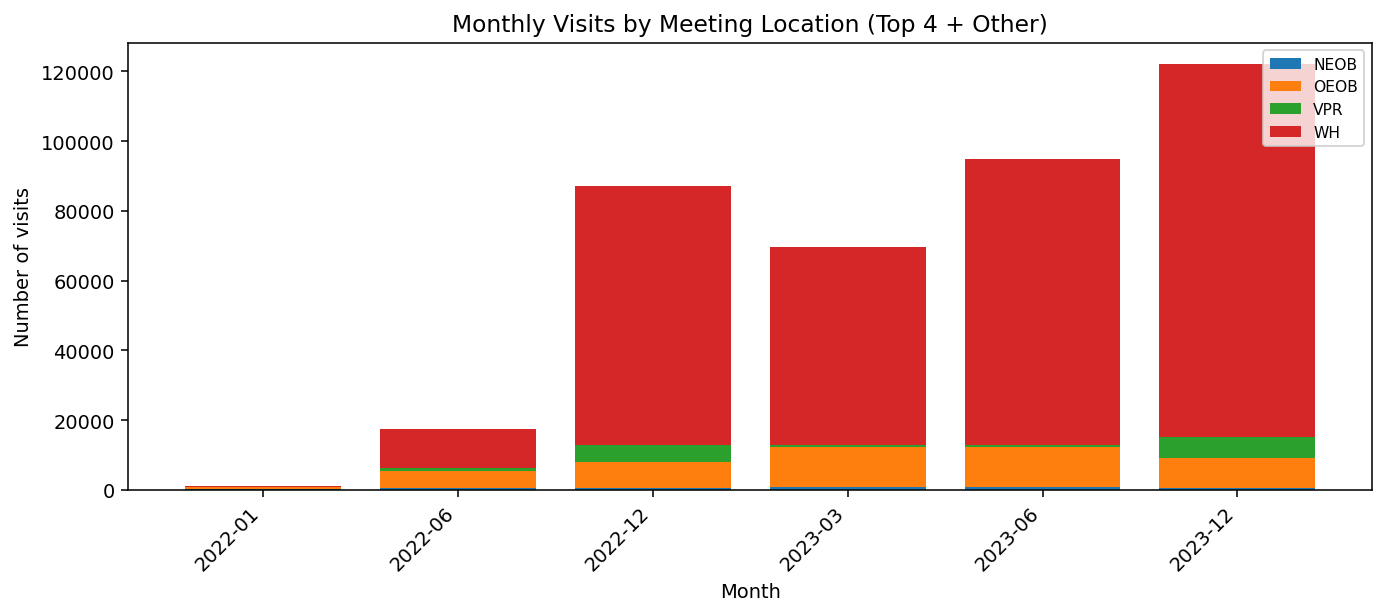

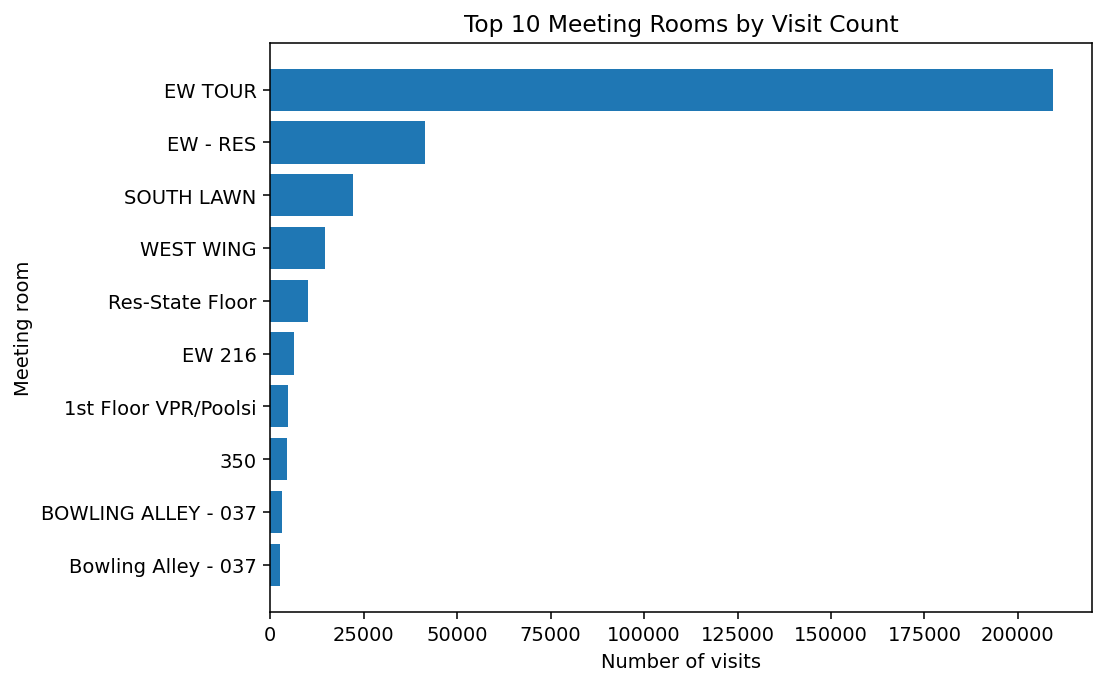

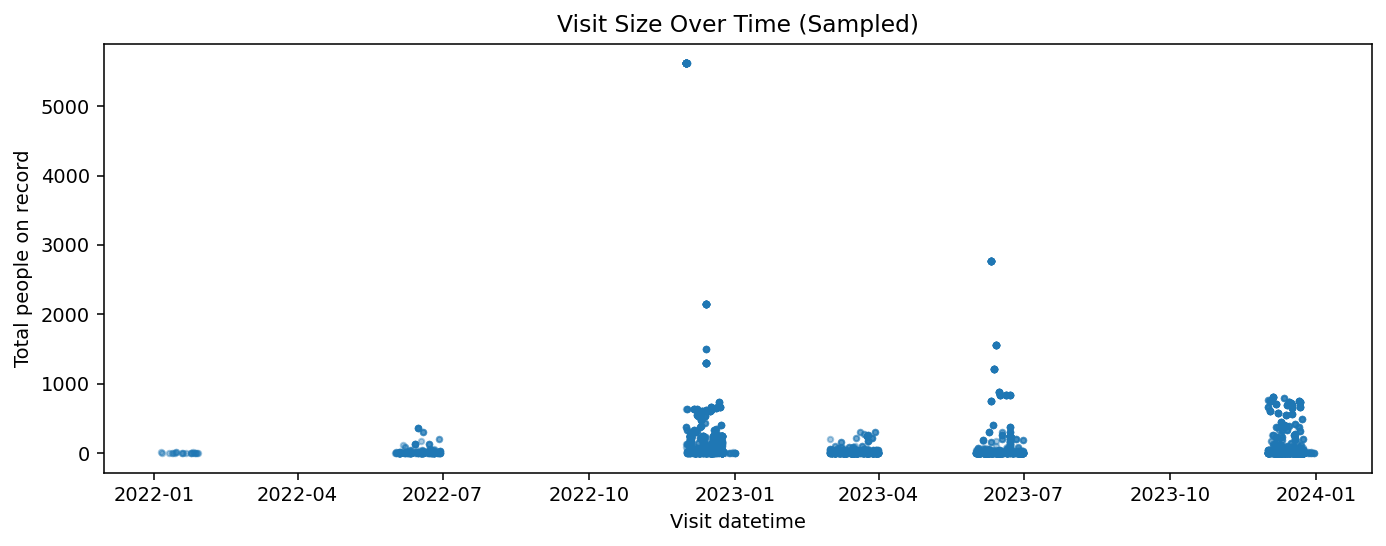

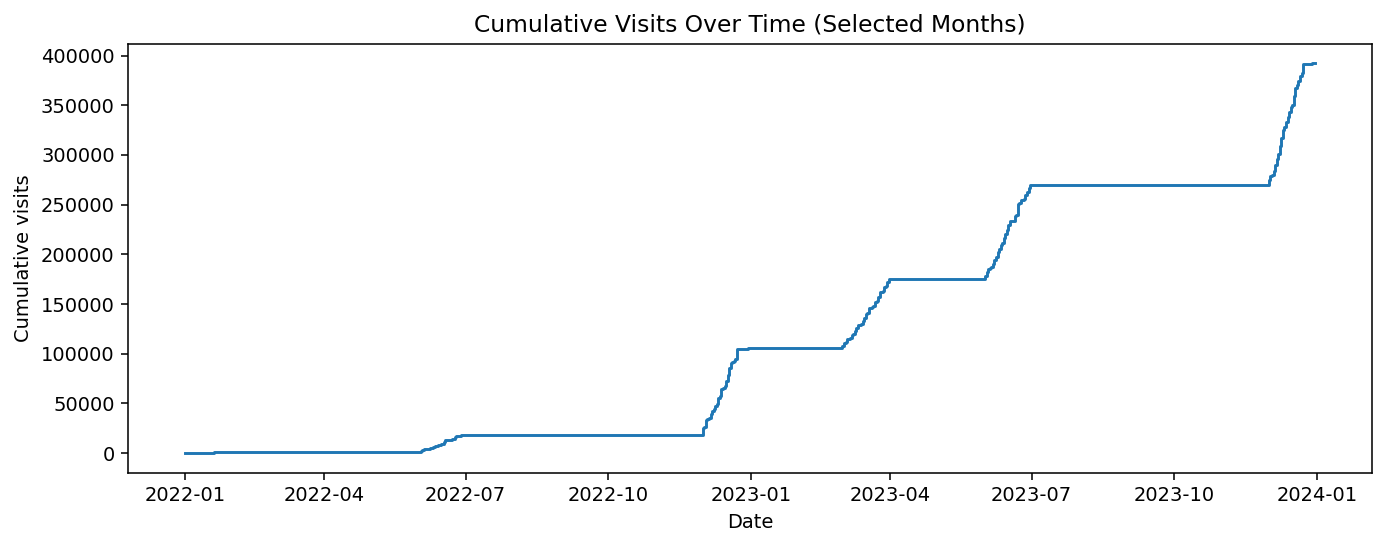

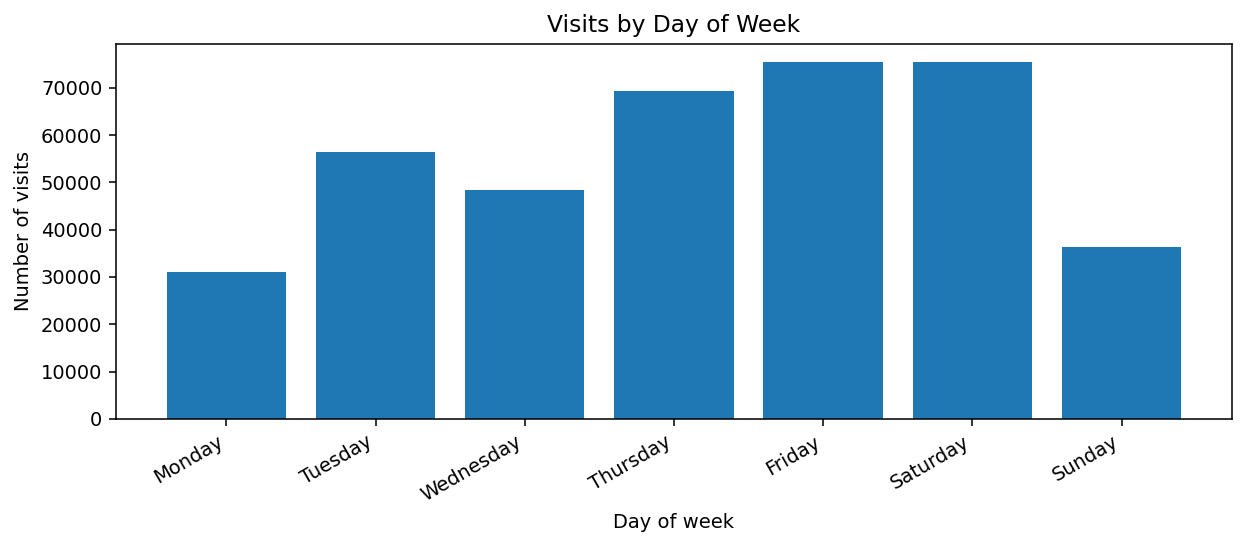

In [9]:
from IPython.display import display, Image

print("========================================")
print("JUPYTER OUTPUT VERIFICATION")
print("========================================\n")

# Show cleaned data preview
print("Cleaned dataset preview (first 10 rows):")
display(df.head(10))

print("\nDataset summary:")
print("Total rows after cleaning:", len(df))
print("Number of datasets used:", df['SOURCE_FILE'].nunique())

print("\nDatasets included:")
display(df['SOURCE_FILE'].value_counts())

# Display all saved figures inline
print("\nDisplaying saved figures:\n")
for p in figure_paths:
    display(Image(filename=p))
